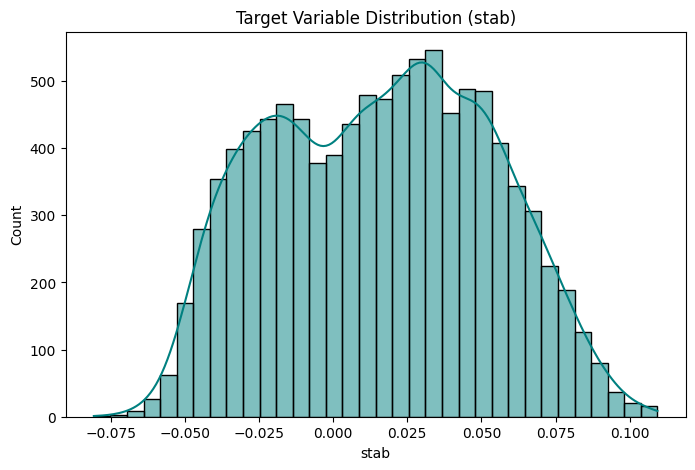

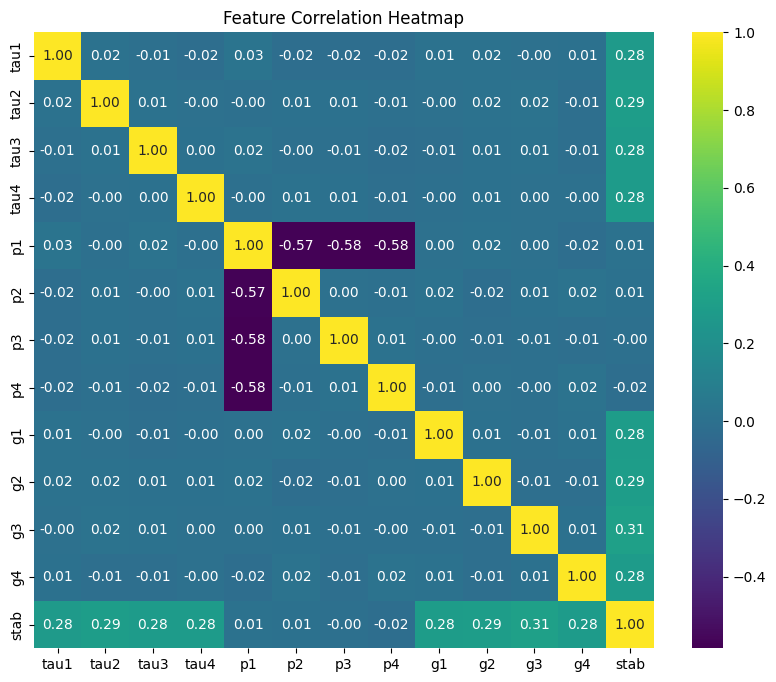

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your CSV data
df = pd.read_csv('/kaggle/input/datasets/sowlarn/ucis-electrical-grid-stability-simulated-data/Data_for_UCI_named.csv')

# 1. Target Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['stab'], kde=True, color='teal')
plt.title('Target Variable Distribution (stab)')
plt.show()

# 2. Correlation Heatmap (To see feature relationships)
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop('stabf', axis=1).corr(), annot=True, cmap='viridis', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# --- 1. Data Preparation ---
X = df.drop(['stab', 'stabf'], axis=1).values
y = df['stab'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling is crucial for Neural Networks
scaler_x, scaler_y = StandardScaler(), StandardScaler()
X_train_s = scaler_x.fit_transform(X_train)
X_test_s = scaler_x.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)

# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32)

# --- 2. Model Architecture ---
class RegressionModel(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = RegressionModel(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# --- 3. Training Loop ---
for epoch in range(100):
    optimizer.zero_grad()
    pred = model(X_train_t)
    loss = criterion(pred, y_train_t)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# --- 4. Evaluation ---
model.eval()
with torch.no_grad():
    y_pred_s = model(X_test_t).numpy()
    y_pred = scaler_y.inverse_transform(y_pred_s)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

print(f"\nEvaluation Results:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R2 Score: {r2:.4f} (Accuracy measure for regression)")

Epoch 0 | Loss: 1.0367
Epoch 20 | Loss: 0.1376
Epoch 40 | Loss: 0.0777
Epoch 60 | Loss: 0.0530
Epoch 80 | Loss: 0.0386

Evaluation Results:
Mean Squared Error (MSE): 0.0001
R2 Score: 0.9579 (Accuracy measure for regression)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data
df = pd.read_csv('/kaggle/input/datasets/sowlarn/ucis-electrical-grid-stability-simulated-data/Data_for_UCI_named.csv')
X = df.drop(['stab', 'stabf'], axis=1).values
y = df['stab'].values.reshape(-1, 1)

# Split into Training (70%) and Testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale data
scaler_x, scaler_y = StandardScaler(), StandardScaler()
X_train_s = torch.tensor(scaler_x.fit_transform(X_train), dtype=torch.float32)
X_test_s = torch.tensor(scaler_x.transform(X_test), dtype=torch.float32)
y_train_s = torch.tensor(scaler_y.fit_transform(y_train), dtype=torch.float32)
y_test_s = torch.tensor(scaler_y.transform(y_test), dtype=torch.float32)

# 2. Architecture
class RobustRegressor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.SiLU(),
            nn.Dropout(0.4), # Dropout helps prevent overfitting
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Dropout(0.3), # Dropout helps prevent overfitting
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model = RobustRegressor(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 3. Training Loop with Overfitting Tracking
epochs = 300
train_history = []
test_history = []

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    optimizer.zero_grad()
    train_pred = model(X_train_s)
    train_loss = criterion(train_pred, y_train_s)
    train_loss.backward()
    optimizer.step()
    
    # --- TESTING/VALIDATION PHASE ---
    model.eval() 
    with torch.no_grad():
        test_pred = model(X_test_s)
        test_loss = criterion(test_pred, y_test_s)
    
    # Save losses for plotting
    train_history.append(train_loss.item())
    test_history.append(test_loss.item())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3} | Train Loss: {train_loss.item():.4f} | Test Loss: {test_loss.item():.4f}")

# 4. Plot Learning Curves
plt.figure(figsize=(10, 6))
plt.plot(train_history, label='Train Loss', color='blue', lw=2)
plt.plot(test_history, label='Test Loss', color='orange', linestyle='--', lw=2)
plt.title('Overfitting Check: Training vs Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

Epoch   0 | Train Loss: 1.0349 | Test Loss: 0.9004
Epoch  20 | Train Loss: 0.2812 | Test Loss: 0.2498
Epoch  40 | Train Loss: 0.1767 | Test Loss: 0.1109
Epoch  60 | Train Loss: 0.1403 | Test Loss: 0.0794
Epoch  80 | Train Loss: 0.1177 | Test Loss: 0.0619
Epoch 100 | Train Loss: 0.1022 | Test Loss: 0.0477
Epoch 120 | Train Loss: 0.0917 | Test Loss: 0.0422
Epoch 140 | Train Loss: 0.0868 | Test Loss: 0.0383
Epoch 160 | Train Loss: 0.0823 | Test Loss: 0.0359
Epoch 180 | Train Loss: 0.0807 | Test Loss: 0.0353
Epoch 200 | Train Loss: 0.0748 | Test Loss: 0.0394
Epoch 220 | Train Loss: 0.0741 | Test Loss: 0.0343
Epoch 240 | Train Loss: 0.0689 | Test Loss: 0.0383
Epoch 260 | Train Loss: 0.0670 | Test Loss: 0.0381
Epoch 280 | Train Loss: 0.0663 | Test Loss: 0.0386
